In [41]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import networkx as nx

from tqdm import tqdm
pd.set_option('display.max_columns', 5000)

In [ ]:
import networkx as nx
import numpy as np

def calculate_netkde_for_month(df_month, cols_to_smooth, bandwidth=150):
    """
    Applies Network Kernel Density Estimation (NetKDE)
    Distributes snapped crime points across neighboring streets using a Gaussian kernel.
    """
    G = nx.Graph()
    for _, row in df_month.iterrows():
        G.add_edge(row['u'], row['v'], edge_id=row['edge_id'], weight=row['length'])
        
    smoothed_scores = {row['edge_id']: {col: 0.0 for col in cols_to_smooth} for _, row in df_month.iterrows()}
    
    event_mask = (df_month[cols_to_smooth] > 0).any(axis=1)
    event_edges = df_month[event_mask]
    
    for _, source_row in event_edges.iterrows():
        source_u = source_row['u']
        
        ego_graph = nx.ego_graph(G, source_u, radius=bandwidth, distance='weight')
        
        try:
            path_lengths = nx.single_source_dijkstra_path_length(ego_graph, source_u, weight='weight')
        except nx.NetworkXNoPath:
            path_lengths = {source_u: 0.0}
        
        sigma = bandwidth / 3.0
        
        for u, v, data in ego_graph.edges(data=True):
            dist_u = path_lengths.get(u, bandwidth)
            dist_v = path_lengths.get(v, bandwidth)
            dist = min(dist_u, dist_v)
            
            decay_weight = np.exp(-0.5 * (dist / sigma) ** 2)
            
            for col in cols_to_smooth:
                source_val = source_row[col]
                if source_val > 0:
                    smoothed_scores[data['edge_id']][col] += (source_val * decay_weight)
            
    for col in cols_to_smooth:
        df_month[col] = df_month['edge_id'].map(lambda eid: smoothed_scores[eid][col])
    
    return df_month

def apply_temporal_netkde(df_long, cols_to_smooth, bandwidth=150):
    """
    Wraps the NetKDE function to apply it month-by-month to avoid data leakage.
    """
    print(f"Applying Spatial NetKDE (Bandwidth: {bandwidth}m) across {len(cols_to_smooth)} features...")
    smoothed_dfs = []
    
    grouped = df_long.groupby('year_month')
    
    for year_month, group in tqdm(grouped, desc="Smoothing Months", unit="month"):
        smoothed_group = calculate_netkde_for_month(group.copy(), cols_to_smooth, bandwidth=bandwidth)
        smoothed_dfs.append(smoothed_group)
        
    return pd.concat(smoothed_dfs, ignore_index=True)

In [56]:
def format_ml(df):
    """
    Transforms a wide-format crime dataset into a long format with lag features for ML.
    """
    
    # 1. Isolate static features
    static_features = [
        'edge_id', 'u', 'u_lat', 'u_lng', 'v', 'v_lat', 'v_lng', 
        'key', 'name', 'highway', 'length'
    ]
    df_static = df[static_features].copy()

    # 2. Isolating time series
    time_cols = [col for col in df.columns if pd.Series(col).str.contains(r'\d{4}_\d{2}$').any()]
    df_time = df[['edge_id'] + time_cols].copy()

    # 3. Condensing all time columns into 'metric' and 'value'
    df_melted = df_time.melt(id_vars='edge_id', var_name='metric_month', value_name='value')

    # 4. Split the melted column into a 'metric' and a 'year_month'
    # e.g., splits 'crime_count_2023_06' -> 'crime_count' and '2023_06'
    extract_regex = r'^(?P<metric>.*)_(?P<year_month>\d{4}_\d{2})$'
    df_melted[['metric', 'year_month']] = df_melted['metric_month'].str.extract(extract_regex)
    df_melted = df_melted.drop(columns=['metric_month'])

    # 5. Pivot: Push the metrics back into their own distinct columns
    df_long = df_melted.pivot(
        index=['edge_id', 'year_month'], 
        columns='metric', 
        values='value'
    ).reset_index()

    # 6. Sort chronologically
    df_long = df_long.sort_values(by=['edge_id', 'year_month'])

    # 7. Engineer Lag Features (1, 2 and 3 months)
    lags = [1, 2, 3]
    metrics_to_lag = ['crime_count', 'crime_severity_sum', 'stop_search_count']

    for metric in metrics_to_lag:
        for lag in lags:
            # Groupby ensures a street only looks at its own history, not the street above it
            df_long[f'{metric}_lag_{lag}'] = df_long.groupby('edge_id')[metric].shift(lag)

    # 8. Drop rows with NaNs caused by the shift (first 3 months)
    df_long = df_long.dropna(subset=[f'crime_count_lag_{lag}' for lag in lags]).reset_index(drop=True)

    # 9. Merge the static street metadata back in
    final_df = pd.merge(df_long, df_static, on='edge_id', how='left')

    # 10. Rename current month metrics to 'target'
    final_df = final_df.rename(columns={
        'crime_count': 'target_crime_count',
        'crime_severity_sum': 'target_crime_severity',
        'stop_search_count': 'target_stop_search'
    })
    # 11. Apply Network KDE Smoothing
    # Application is done on all relevant columns
    features_to_smooth = [
        'target_crime_count', 
        'target_crime_severity', 
        'target_stop_search',
        'crime_count_lag_1', 
        'crime_count_lag_2', 
        'crime_count_lag_3', 
        'crime_severity_sum_lag_1', 
        'crime_severity_sum_lag_2', 
        'crime_severity_sum_lag_3',
        'stop_search_count_lag_1', 
        'stop_search_count_lag_2', 
        'stop_search_count_lag_3'
    ]
    
    final_df = apply_temporal_netkde(final_df, cols_to_smooth=features_to_smooth, bandwidth=150)
    

    return final_df



In [55]:
def train_crime_model(ml_ready_df):
    """
    Trains the simple XGBoost ML model
    """
    # 1. Define the chronological cutoff (e.g., hold out the last 3 months for testing)
    # Based on your data ending in 2026_05, let's test on Spring 2026
    cutoff_month = '2026_03'
    
    # 2. Split into Train (Past) and Test (Future)
    train_df = ml_ready_df[ml_ready_df['year_month'] < cutoff_month].copy()
    test_df = ml_ready_df[ml_ready_df['year_month'] >= cutoff_month].copy()
    
    print(f"Training on {len(train_df)} records (Before {cutoff_month})")
    print(f"Testing on {len(test_df)} records ({cutoff_month} onwards)")

    # 3. Define the Target (y)
    target_col = 'target_crime_count'
    
    # 4. Define Features (X)
    # Drop identifiers, metadata strings, and concurrent targets
    cols_to_drop = [
        'edge_id', 'year_month', 'name', 'u', 'v', 'key', # Drop identifiers
        'target_crime_count', 'target_crime_severity', 'target_stop_search' # Drop ALL concurrent targets
    ]
    
    # Optional: Convert 'highway' (categorical string) to a Pandas category dtype 
    # so XGBoost can handle it natively without one-hot encoding.
    train_df['highway'] = train_df['highway'].astype('category')
    test_df['highway'] = test_df['highway'].astype('category')
    
    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=cols_to_drop)
    y_test = test_df[target_col]

    # 5. Initialize XGBoost Regressor
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50,
        objective='count:poisson'
    )

    # 6. Train the model
    print("Training XGBoost...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=50 # Print progress every 50 trees
    )

    # 7. Evaluate the predictions
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    print(f"\nMean Absolute Error (MAE): {mae:.2f} crimes per street")
    
    return model, X_train.columns



In [45]:
def feature_importance(model, X_train):
    """
    Extracts feature importance and displays in a bar chart.
    """
    # 1. Visual Plot: Using XGBoost's built-in plotter
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # We use importance_type='gain' because it measures predictive power
    xgb.plot_importance(
        model, 
        importance_type='gain', 
        max_num_features=15, # Only show the top 15 features
        ax=ax, 
        height=0.5,
        color='steelblue'
    )
    plt.title("Top 15 Most Predictive Features (by Information Gain)")
    plt.show()

    # 2. Raw Data: Extracting into a Pandas DataFrame
    importance_dict = model.get_booster().get_score(importance_type='gain')
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Gain': list(importance_dict.values())
    })
    
    # Sort from most to least important
    importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    print("\nFeature Importance Rankings:")
    print(importance_df.head(15))
    
    return importance_df

In [46]:

def predict_and_map_to_nodes(ml_ready_df, model, feature_columns, latest_month='2026_05'):
    """
    Predicts crime for the next month, calculates safety cost, and maps to OSM nodes.
    """
    # If a full DataFrame was passed instead of a list of columns, extract the column names
    if isinstance(feature_columns, pd.DataFrame):
        feature_columns = feature_columns.columns.tolist()
    elif hasattr(feature_columns, 'tolist'):
        feature_columns = feature_columns.tolist()
    
    # ==========================================
    # 1. Prepare Future Data (Shift Lags Forward)
    # ==========================================
    latest_data = ml_ready_df[ml_ready_df['year_month'] == latest_month].copy()
    future_data = latest_data.copy()
    
    # Shift the lags forward by 1 month
    future_data['crime_count_lag_1'] = latest_data['target_crime_count']
    future_data['crime_count_lag_2'] = latest_data['crime_count_lag_1']
    future_data['crime_count_lag_3'] = latest_data['crime_count_lag_2']
    
    future_data['crime_severity_sum_lag_1'] = latest_data['target_crime_severity']
    future_data['crime_severity_sum_lag_2'] = latest_data['crime_severity_sum_lag_1']
    future_data['crime_severity_sum_lag_3'] = latest_data['crime_severity_sum_lag_2']
    
    future_data['stop_search_count_lag_1'] = latest_data['target_stop_search']
    future_data['stop_search_count_lag_2'] = latest_data['stop_search_count_lag_1']
    future_data['stop_search_count_lag_3'] = latest_data['stop_search_count_lag_2']
    
    # CRITICAL FIX: Explicitly force 'highway' to be a category type before prediction
    if 'highway' in future_data.columns:
        future_data['highway'] = future_data['highway'].astype('category')
    
    # Extract only the features the model was trained on
    X_future = future_data[feature_columns]

    # ==========================================
    # 2. Generate Predictions
    # ==========================================
    print("Predicting future crime counts...")
    future_data['predicted_crime'] = model.predict(X_future)
    future_data['predicted_crime'] = future_data['predicted_crime'].clip(lower=0)

    # ==========================================
    # 3. Calculate "Safety Cost" for the Edges
    # ==========================================
    # Calculate raw density
    future_data['crime_density'] = future_data['predicted_crime'] / future_data['length']
    
    # 1. Apply Log1p (Logarithmic transformation: log(1 + x))
    # This prevents outliers from squashing the rest of the data
    future_data['log_density'] = np.log1p(future_data['crime_density'])
    
    max_density = future_data['log_density'].max()
    min_density = future_data['log_density'].min()
    
    # 2. Safety Check: If the model predicted exactly 0 for literally every street
    if max_density == min_density:
        print("Warning: The model predicted the exact same value for all streets. Cost is flat.")
        future_data['safety_tag_value'] = 1.0
    else:
        # 3. Scale using the log-transformed values
        future_data['safety_tag_value'] = 1 + ((future_data['log_density'] - min_density) / (max_density - min_density) * 10)

    # ==========================================
    # 4. Map Edge Costs onto OSM Nodes (u and v)
    # ==========================================
    u_nodes = future_data[['u', 'u_lat', 'u_lng', 'safety_tag_value']].rename(
        columns={'u': 'node_id', 'u_lat': 'lat', 'u_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    v_nodes = future_data[['v', 'v_lat', 'v_lng', 'safety_tag_value']].rename(
        columns={'v': 'node_id', 'v_lat': 'lat', 'v_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    
    all_nodes = pd.concat([u_nodes, v_nodes])
    
    node_safety_df = all_nodes.groupby('node_id').agg(
        node_safety_cost=('cost', 'mean'),
        lat=('lat', 'first'),
        lng=('lng', 'first')
    ).reset_index()

    node_safety_df = node_safety_df.sort_values(by='node_safety_cost', ascending=False).reset_index(drop=True)
    
    print("\nTop 5 Highest Risk Nodes:")
    print(node_safety_df.head())
    
    return future_data, node_safety_df

In [47]:
def osm_tag_mapping(future_edges_df):
    """
    Creates a clean mapping of OSM Way IDs to Safety Costs.
    """
    df = future_edges_df.copy()
    
    # We round the safety cost to an integer (1-10) to make the Valhalla Lua costing easier
    df['safety_tag_value'] = df['safety_tag_value'].round().astype(int)
    
    # Isolate just the OSM ID and the new Tag Value
    osm_tags = df[['edge_id', 'safety_tag_value']].drop_duplicates()
    
    osm_tags.to_csv('osm_safety_tags.csv', index=False)
    print("Saved OSM Tag mapping. Use this to tag your .osm.pbf file.")

In [57]:
df = pd.read_csv('data_out/edge_features.csv')

df_ml = format_ml(df)

Applying Spatial NetKDE (Bandwidth: 150m) across 12 features...


Smoothing Months: 100%|██████████| 33/33 [01:30<00:00,  2.73s/month]


In [ ]:
df.head()

,edge_id,u,u_lat,u_lng,v,v_lat,v_lng,key,name,highway,length,crime_count,crime_severity_sum,stop_search_count,crime_count_2023_06,crime_count_2023_07,crime_count_2023_08,crime_count_2023_09,crime_count_2023_10,crime_count_2023_11,crime_count_2023_12,crime_count_2024_01,crime_count_2024_02,crime_count_2024_03,crime_count_2024_04,crime_count_2024_05,crime_count_2024_06,crime_count_2024_07,crime_count_2024_08,crime_count_2024_09,crime_count_2024_10,crime_count_2024_11,crime_count_2024_12,crime_count_2025_01,crime_count_2025_02,crime_count_2025_03,crime_count_2025_04,crime_count_2025_05,crime_count_2025_06,crime_count_2025_07,crime_count_2025_08,crime_count_2025_09,crime_count_2025_10,crime_count_2025_11,crime_count_2025_12,crime_count_2026_01,crime_count_2026_02,crime_count_2026_03,crime_count_2026_04,crime_count_2026_05,crime_severity_sum_2023_06,crime_severity_sum_2023_07,crime_severity_sum_2023_08,crime_severity_sum_2023_09,crime_severity_sum_2023_10,crime_severity_sum_2023_11,crime_severity_sum_2023_12,crime_severity_sum_2024_01,crime_severity_sum_2024_02,crime_severity_sum_2024_03,crime_severity_sum_2024_04,crime_severity_sum_2024_05,crime_severity_sum_2024_06,crime_severity_sum_2024_07,crime_severity_sum_2024_08,crime_severity_sum_2024_09,crime_severity_sum_2024_10,crime_severity_sum_2024_11,crime_severity_sum_2024_12,crime_severity_sum_2025_01,crime_severity_sum_2025_02,crime_severity_sum_2025_03,crime_severity_sum_2025_04,crime_severity_sum_2025_05,crime_severity_sum_2025_06,crime_severity_sum_2025_07,crime_severity_sum_2025_08,crime_severity_sum_2025_09,crime_severity_sum_2025_10,crime_severity_sum_2025_11,crime_severity_sum_2025_12,crime_severity_sum_2026_01,crime_severity_sum_2026_02,crime_severity_sum_2026_03,crime_severity_sum_2026_04,crime_severity_sum_2026_05,stop_search_count_2023_06,stop_search_count_2023_07,stop_search_count_2023_08,stop_search_count_2023_09,stop_search_count_2023_10,stop_search_count_2023_11,stop_search_count_2023_12,stop_search_count_2024_01,stop_search_count_2024_02,stop_search_count_2024_03,stop_search_count_2024_04,stop_search_count_2024_05,stop_search_count_2024_06,stop_search_count_2024_07,stop_search_count_2024_08,stop_search_count_2024_09,stop_search_count_2024_10,stop_search_count_2024_11,stop_search_count_2024_12,stop_search_count_2025_01,stop_search_count_2025_02,stop_search_count_2025_03,stop_search_count_2025_04,stop_search_count_2025_05,stop_search_count_2025_06,stop_search_count_2025_07,stop_search_count_2025_08,stop_search_count_2025_09,stop_search_count_2025_10,stop_search_count_2025_11,stop_search_count_2025_12,stop_search_count_2026_01,stop_search_count_2026_02,stop_search_count_2026_03,stop_search_count_2026_04,stop_search_count_2026_05,crime_per_km,crime_severity_per_km,crime_avg_severity,stop_search_per_km
0,0,78112,51.526976,-0.145792,13847176073,51.526978,-0.145670,0,Cambridge Terrace,residential,8.450054,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000
1,1,13847176073,51.526978,-0.145670,78112,51.526976,-0.145792,0,Cambridge Terrace,residential,8.450054,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000
2,2,13847176073,51.526978,-0.145670,13847176072,51.526801,-0.145667,0,NaN,footway,19.738369,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000
3,3,13847176073,51.526978,-0.145670,13847176075,51.527549,-0.145685,0,NaN,footway,63.433498,0,0,0,0,0,0,0,0,0,0,0,0,0

In [59]:
model, X_train = train_crime_model(df_ml)

Training on 1065240 records (Before 2026_03)
Testing on 106524 records (2026_03 onwards)
Training XGBoost...
[0]	validation_0-poisson-nloglik:5.11972	validation_1-poisson-nloglik:4.62105
[50]	validation_0-poisson-nloglik:1.76686	validation_1-poisson-nloglik:1.66602
[100]	validation_0-poisson-nloglik:1.07999	validation_1-poisson-nloglik:1.08284
[150]	validation_0-poisson-nloglik:0.95708	validation_1-poisson-nloglik:0.96787
[200]	validation_0-poisson-nloglik:0.92498	validation_1-poisson-nloglik:0.93938
[250]	validation_0-poisson-nloglik:0.91501	validation_1-poisson-nloglik:0.93263
[300]	validation_0-poisson-nloglik:0.91089	validation_1-poisson-nloglik:0.93159
[350]	validation_0-poisson-nloglik:0.90800	validation_1-poisson-nloglik:0.93110
[400]	validation_0-poisson-nloglik:0.90530	validation_1-poisson-nloglik:0.93076
[450]	validation_0-poisson-nloglik:0.90236	validation_1-poisson-nloglik:0.93042
[499]	validation_0-poisson-nloglik:0.89989	validation_1-poisson-nloglik:0.93031

Mean Absolute

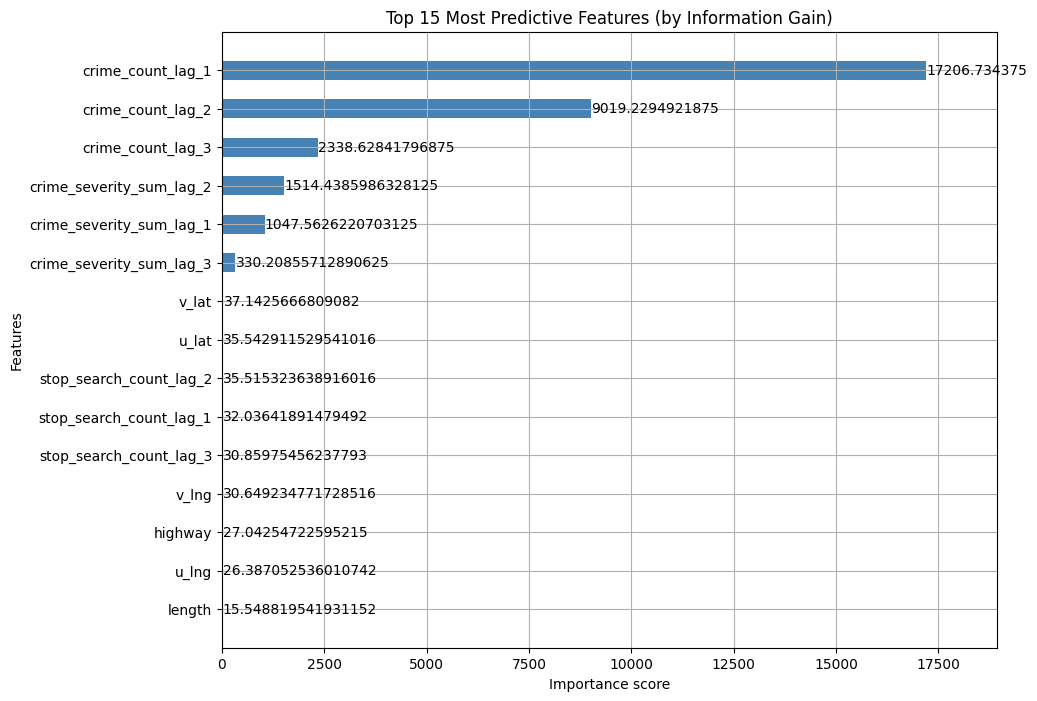


Feature Importance Rankings:
                     Feature          Gain
0          crime_count_lag_1  17206.734375
1          crime_count_lag_2   9019.229492
2          crime_count_lag_3   2338.628418
3   crime_severity_sum_lag_2   1514.438599
4   crime_severity_sum_lag_1   1047.562622
5   crime_severity_sum_lag_3    330.208557
6                      v_lat     37.142567
7                      u_lat     35.542912
8    stop_search_count_lag_2     35.515324
9    stop_search_count_lag_1     32.036419
10   stop_search_count_lag_3     30.859755
11                     v_lng     30.649235
12                   highway     27.042547
13                     u_lng     26.387053
14                    length     15.548820


,Feature,Gain
0,crime_count_lag_1,17206.734375
1,crime_count_lag_2,9019.229492
2,crime_count_lag_3,2338.628418
3,crime_severity_sum_lag_2,1514.438599
4,crime_severity_sum_lag_1,1047.562622
5,crime_severity_sum_lag_3,330.208557
6,v_lat,37.142567
7,u_lat,35.542912
8,stop_search_count_lag_2,35.515324
9,stop_search_count_lag_1,32.036419


In [60]:
feature_importance(model, X_train)

In [61]:
future_edges, future_node = predict_and_map_to_nodes(df_ml, model, X_train, latest_month='2026_05')

Predicting future crime counts...

Top 5 Highest Risk Nodes:
       node_id  node_safety_cost        lat       lng
0  12979559034          6.077006  51.545793 -0.178086
1  13654121755          4.683149  51.519619 -0.106182
2   1202903960          4.183548  51.541613 -0.145979
3    252036607          3.739746  51.553617 -0.166285
4   5501951425          3.555020  51.520658 -0.106116


In [62]:
osm_tag_mapping(future_edges)

Saved OSM Tag mapping. Use this to tag your .osm.pbf file.


In [63]:
future_edges['predicted_crime'].describe()

count    35508.000000
mean         2.599063
std          6.201877
min          0.001070
25%          0.003104
50%          0.006562
75%          2.585826
max         87.855316
Name: predicted_crime, dtype: float64